In [8]:
# Import audio processing and plotting libraries
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from matplotlib import rcParams

# Configure plot appearance settings
rcParams['font.family'] = 'serif'           # Use serif font family
rcParams['font.serif'] = ['Times New Roman'] # Set Times New Roman as the specific font

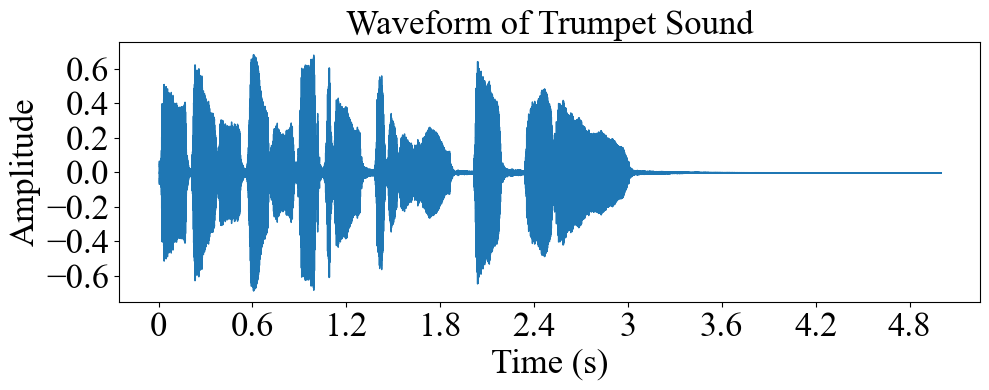

Signal saved to 'trumpet_signal.txt' with 110250 samples.


In [9]:
# Load the example 'trumpet' audio file provided by librosa (limit to 5 seconds)
y, sr = librosa.load(librosa.example('trumpet'), duration=5.0)

# -------- Plot waveform of the audio signal --------
plt.figure(figsize=(10, 4))  # Figure size
librosa.display.waveshow(y, sr=sr)  # Plot the audio waveform
plt.title('Waveform of Trumpet Sound', fontsize=25)  # Plot title
plt.xlabel('Time (s)', fontsize=25)  # X-axis: time in seconds
plt.ylabel('Amplitude', fontsize=25)  # Y-axis: signal amplitude
plt.xticks(fontsize=25)  # X tick label font size
plt.yticks(fontsize=25)  # Y tick label font size
plt.tight_layout()  # Adjust layout to avoid clipping
plt.show()

# --- SAVE THE SIGNAL INTO A .TXT FILE ---
np.savetxt("DATA/trumpet_signal.txt", y)  # Save raw samples to a text file

print(f"Signal saved to 'trumpet_signal.txt' with {len(y)} samples.")

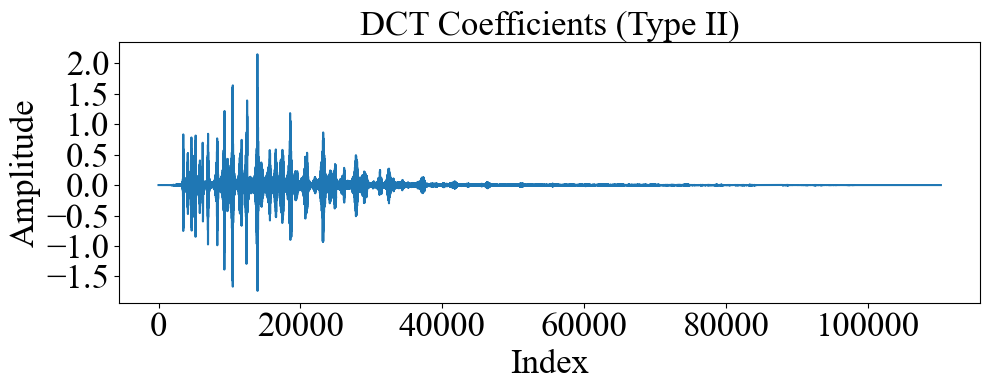

In [15]:
from scipy.fftpack import dct
import matplotlib.pyplot as plt

# Read the signal samples from the text file saved earlier
signal = np.loadtxt("DATA/trumpet_signal.txt")

# Compute DCT (Discrete Cosine Transform) type II, commonly used for spectral analysis
dct_coeffs = dct(signal, type=2, norm='ortho')

# Plot the DCT coefficients to visualize spectral content
plt.figure(figsize=(10, 4))
plt.plot(dct_coeffs)  # Display the DCT coefficients
plt.title("DCT Coefficients (Type II)", fontsize=25)
plt.xlabel("Index", fontsize=25)  # Coefficient index
plt.ylabel("Amplitude", fontsize=25)  # Coefficient amplitude
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
# plt.xlim(0, 10000)  # Limit x-axis to first 10000 coefficients
plt.tight_layout()
plt.show()


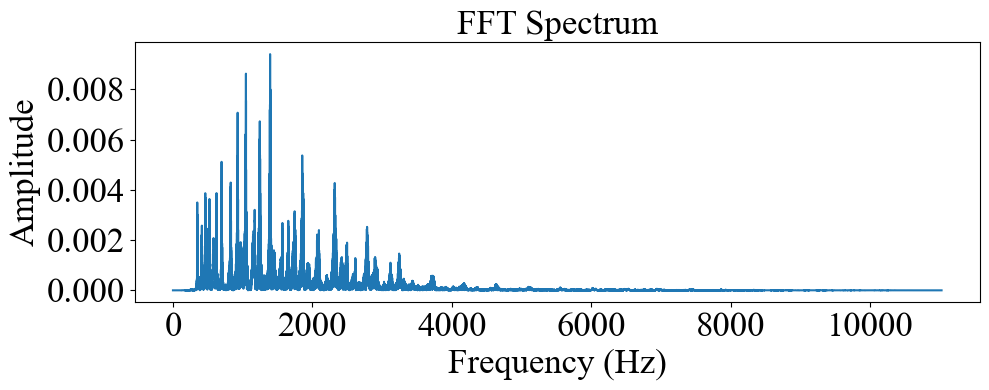

In [11]:
from scipy.fft import fft, fftfreq

# Prepare FFT inputs: number of samples and sampling interval
N = len(signal)          # Number of samples
T = 1.0 / sr             # Sampling interval (seconds per sample)
yf = fft(signal)         # Compute the discrete Fourier transform
xf = fftfreq(N, T)[:N//2]  # Positive frequency axis (Hz)

# Plot the FFT magnitude spectrum (single-sided)
plt.figure(figsize=(10, 4))
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]))  # Scale the magnitude for single-sided spectrum
plt.title("FFT Spectrum", fontsize=25)
plt.xlabel("Frequency (Hz)", fontsize=25)
plt.ylabel("Amplitude", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tight_layout()
plt.show()


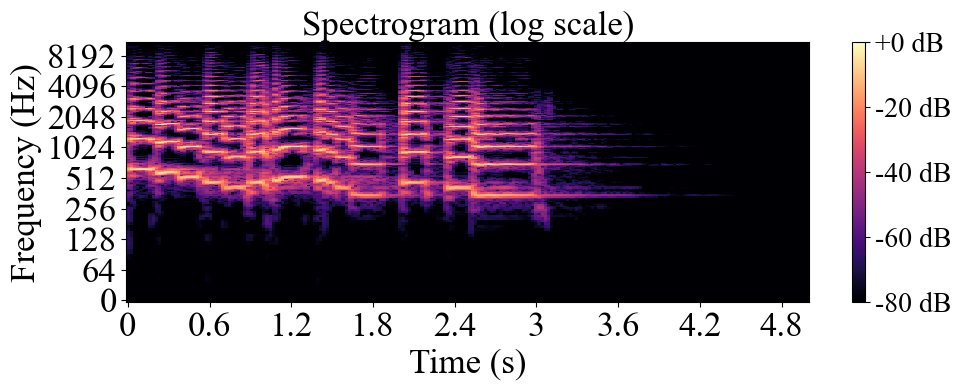

In [12]:
import librosa
import librosa.display

# Compute STFT (Short-Time Fourier Transform) and convert to decibel scale
S = librosa.stft(signal)  # STFT matrix (complex-valued)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)  # Convert magnitude to dB scale

# Plot the spectrogram using a logarithmic frequency axis
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log', cmap='magma')
ax = plt.colorbar(format='%+2.0f dB')
ax.ax.tick_params(labelsize=20)  # Set colorbar tick label font size to 20
plt.title("Spectrogram (log scale)", fontsize=25)
plt.xlabel("Time (s)", fontsize=25)
plt.ylabel("Frequency (Hz)", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tight_layout()
plt.show()